#### Model Prediction

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("insurance_cleaned.csv")

#### Encode Categorical Variables

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\HP\AppData\Local\Temp\ipykernel_7684\1843634754.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


#### Separate Features and Target

In [5]:
X = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

#### Split Dataset into Training and Testing Sets

#### 80% of the data is used for training and 20% is reserved for testing.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Logistic Regression
#### Logistic Regression is used as a baseline model for binary classification.

In [7]:
from sklearn.linear_model import LogisticRegression

In [8]:
lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Pandas 3 changes how string columns are handled.

In [9]:
categorical_cols = df.select_dtypes(
    include=['object', 'string']
).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

### Using standard scakler to scale the values for better results 

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Logistic Regression works best when features are scaled.

#### Your dataset contains features like:

#### age ≈ 20–60
#### total_claim_amount ≈ 0–100000
#### umbrella_limit ≈ 0–10000000

#### Because the scales differ greatly, optimization struggles.

In [11]:
lr = LogisticRegression(
    max_iter=10000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [12]:
print(lr_pred)

[0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 1 1 0 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]


####  Feature Scaling

#### Feature scaling was applied only to Logistic Regression because optimization-based algorithms are sensitive to differences in feature magnitudes. Tree-based models such as Decision Trees, Random Forests, and XGBoost were trained on the original feature space, as they are inherently scale-invariant.

#### # Decision Tree

Decision Tree captures nonlinear relationships between features and the target variable.

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [16]:
print(dt_pred)

[0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0
 0 0 1 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0]


# Random Forest

Random Forest combines multiple decision trees and generally provides better performance and robustness.

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [19]:
print(rf_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# XGBoost

XGBoost is an ensemble boosting algorithm that often achieves state-of-the-art performance for classification tasks.

In [22]:
!pip install xgboost
from xgboost import XGBClassifier

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 9.7 MB/s eta 0:00:08
   - -------------------------------------- 2.9/69.5 MB 8.9 MB/s eta 0:00:08
   -- ------------------------------------- 4.2/69.5 MB 7.5 MB/s eta 0:00:09
   --- ------------------------------------ 5.2/69.5 MB 7.0 MB/s eta 0:00:10
   --- ------------------------------------ 6.0/69.5 MB 6.6 MB/s eta 0:00:10
   --- ------------------------------------ 6.3/69.5 MB 6.0 MB/s eta 0:00:11
   --- ------------------------------------ 6.3/69.5 MB 6.0 MB/s eta 0:00:11
   --- ------------------------------------ 6.6/69.5 MB 4.4 MB/s eta 0:00:15
   --- ------------------------------------ 6.8/69.5 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 7.1/69.5 MB 3.7 MB/s eta 0:00:18
   ---- ----------------------------------- 7.1/69.5 MB 3.7 MB/s eta 0:00:18
   ---- ----------------------------------- 7.6/69.5 MB 3.0 MB/s eta 0:00:21
   ---


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [24]:
print(xgb_pred)

[0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0
 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0
 0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]


# Performance Evaluation

Models are evaluated using Accuracy, Precision, Recall, and F1-score.

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

In [26]:
models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

results = []

for name, pred in models.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.800,0.666667,0.367347,0.473684
1,Decision Tree,0.805,0.608696,0.571429,0.589474
2,Random Forest,0.775,0.566667,0.346939,0.430380
3,XGBoost,0.815,0.642857,0.551020,0.593407


# Classification Report

The classification report provides precision, recall, F1-score, and support for each class.

In [27]:
print("Random Forest Classification Report\n")

print(classification_report(y_test, rf_pred))

Random Forest Classification Report

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       151
           1       0.57      0.35      0.43        49

    accuracy                           0.78       200
   macro avg       0.69      0.63      0.65       200
weighted avg       0.75      0.78      0.75       200



# Confusion Matrix

The confusion matrix visualizes True Positives, True Negatives, False Positives, and False Negatives.

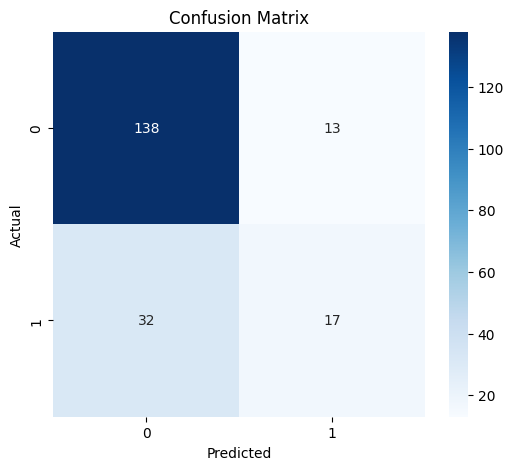

In [28]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ROC Curve

ROC Curve illustrates the trade-off between True Positive Rate and False Positive Rate.

The Area Under Curve (AUC) measures overall classification performance.

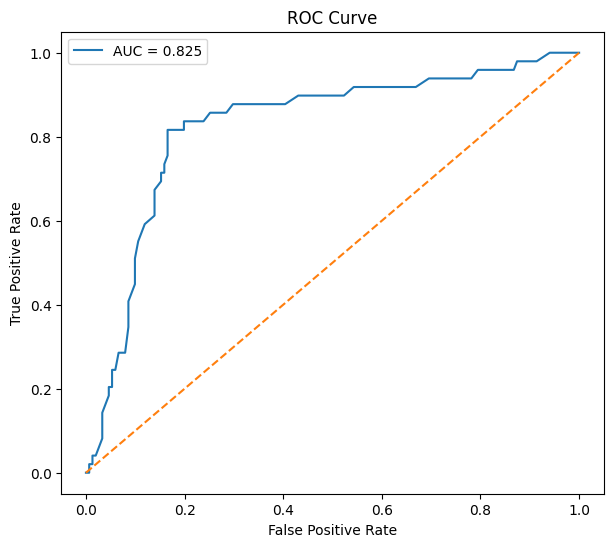

In [29]:
rf_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

auc_score = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Feature Importance

Random Forest feature importance helps identify which variables contribute most to fraud prediction.

In [30]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(15)

incident_severity           0.173123
insured_hobbies             0.087476
property_claim              0.043917
vehicle_claim               0.040188
policy_annual_premium       0.039534
incident_date               0.038774
total_claim_amount          0.036957
months_as_customer          0.036627
injury_claim                0.036272
policy_bind_date            0.032315
auto_model                  0.030579
claim_delay_days            0.029505
insured_occupation          0.029247
age                         0.026733
incident_hour_of_the_day    0.025082
dtype: float64

#### Visualize Feature Importance

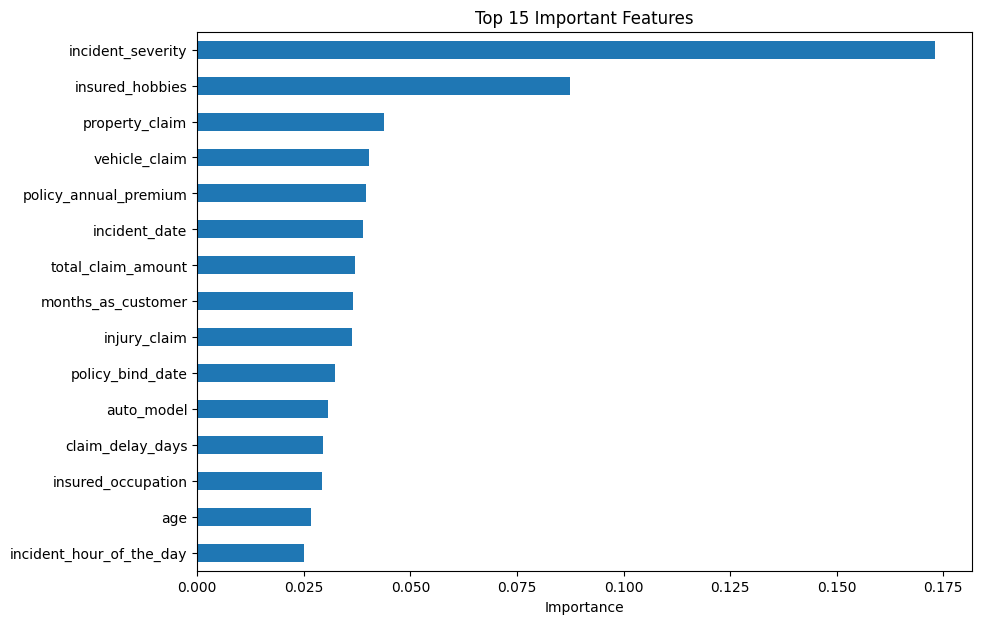

In [31]:
plt.figure(figsize=(10,7))

feature_importance.head(15).sort_values().plot(
    kind='barh'
)

plt.xlabel("Importance")
plt.title("Top 15 Important Features")

plt.show()

# Save Model

The trained Random Forest model is serialized and saved for future deployment and inference.

In [32]:
joblib.dump(
    rf,
    "fraud_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Conclusion

Four machine learning models were trained and compared for insurance fraud detection.

Among them, Random Forest and XGBoost demonstrated superior performance.

Feature importance analysis revealed the most influential variables contributing to fraud prediction, and the final model was saved for future deployment.